# Black Friday purchases

## Question

Which customer groups spend more in this file, and can gender, age, city, and marital status predict an individual amount?

## What one row is

Each row is one customer-product purchase record: a `User_ID`, a `Product_ID`, a `Product_Category`, and a `Purchase` amount. The file does not identify a basket or a full store transaction, so a row is not called a complete transaction.

This analysis uses three different quantities. They are not interchangeable.

1. `Purchase` on one row: the amount on that customer-product record.
2. Total observed spend for a customer: the sum of `Purchase` for that `User_ID` inside this file.
3. Future spend or lifetime value: not measured here. Nothing in the file is a later time period.

## Source and limits

This copy has 550,068 rows and the columns of the public Black Friday retail dataset circulated from the Analytics Vidhya hackathon and Kaggle mirrors such as [sdolezel/black-friday](https://www.kaggle.com/datasets/sdolezel/black-friday). This file keeps a single `Product_Category` column. The common public file also has `Product_Category_2` and `Product_Category_3`.

The repository does not include an original data dictionary. The file has no currency field and no date column. Some republished descriptions call the amount US dollars and the event Black Friday. This notebook does not treat that as confirmed. Amounts are reported as monetary units. The file name says Walmart; that is not evidence that these are official Walmart records. The observation period cannot be confirmed from the file. Results describe this sample only.


## 1. Load and inspect

The first look is the raw table: columns, missing values, duplicate rows, and whether each customer's gender, age, city, and marital status stay the same on every row.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

# one row per customer-product record
purchases = pd.read_csv("Data/walmart_data.csv")
purchases.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [2]:
# row count, column names, and value types
print("Rows:", len(purchases))
print("Columns:", list(purchases.columns))
print(purchases.dtypes)


Rows: 550068
Columns: ['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category', 'Purchase']
User_ID                       int64
Product_ID                      str
Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years      str
Marital_Status                int64
Product_Category              int64
Purchase                      int64
dtype: object


In [3]:
# missing cells and fully duplicated rows
print("Missing values:")
print(purchases.isna().sum())
print("Duplicate rows:", int(purchases.duplicated().sum()))


Missing values:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


Duplicate rows: 0


In [4]:
# a customer attribute is consistent when every row for that User_ID has one value
person_attributes = [
    "Gender",
    "Age",
    "Occupation",
    "City_Category",
    "Stay_In_Current_City_Years",
    "Marital_Status",
]
for column in person_attributes:
    values_per_user = purchases.groupby("User_ID")[column].nunique()
    inconsistent_users = int((values_per_user > 1).sum())
    print(column, "users with more than one value:", inconsistent_users)


Gender users with more than one value: 0
Age users with more than one value: 0


Occupation users with more than one value: 0


City_Category users with more than one value: 0
Stay_In_Current_City_Years users with more than one value: 0


Marital_Status users with more than one value: 0


### Observation

There are 550,068 records, 5,891 customers, and 3,631 products. No column has missing values, and no row is duplicated.

Gender, age, occupation, city, years in the current city, and marital status are constant within each `User_ID`. Later customer tables can keep the first value of each attribute without mixing two answers for the same person.

`Stay_In_Current_City_Years` includes the label `4+`. That means four or more years, not exactly four. The label is kept as text.


## 2. What the records look like

Occupation, city, age, and product category are codes or bands. They are drawn as bars. `Purchase` is the only amount, so it is the histogram. `User_ID` and `Product_ID` are identifiers. Their average is not a meaningful statistic.


In [5]:
# amount on one record, not an identifier
print(purchases["Purchase"].describe())
print("Skewness of Purchase:", float(purchases["Purchase"].skew()))


count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64


Skewness of Purchase: 0.6001400037087126


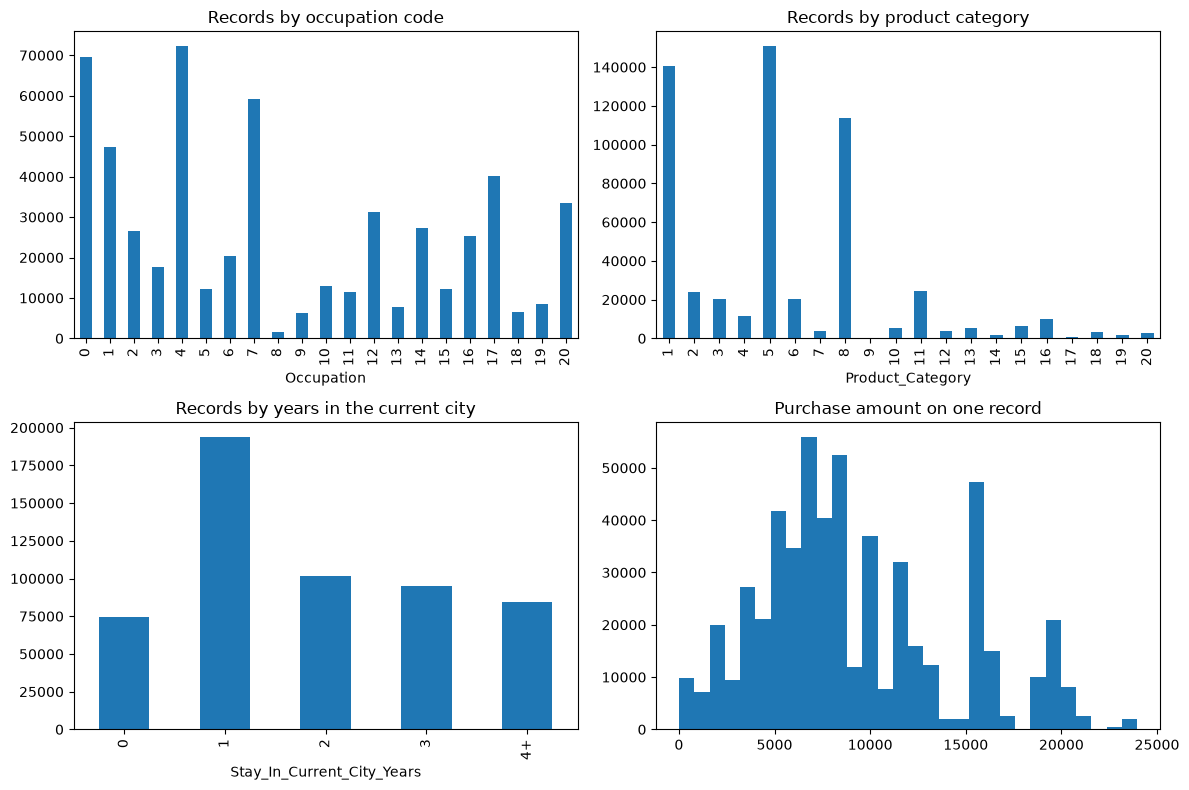

In [6]:
# counts of category codes, plus the shape of the purchase amount
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
purchases["Occupation"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], title="Records by occupation code")
purchases["Product_Category"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], title="Records by product category")
purchases["Stay_In_Current_City_Years"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0], title="Records by years in the current city")
axes[1, 1].hist(purchases["Purchase"], bins=30)
axes[1, 1].set_title("Purchase amount on one record")
fig.tight_layout()


### Observation

`Purchase` on one record has a long right tail: the mean is above the median. Occupation and product category are uneven codes, not smooth numeric distributions. The `4+` bar is its own group.


## 3. One row per customer

The customer question uses total observed spend: the sum of `Purchase` for that `User_ID` in this file. Purchases from the same person are not treated as independent observations in the group comparisons.


In [7]:
# total observed spend, plus the person attributes that do not change within the user
customers = purchases.groupby("User_ID").agg(
    total_spend=("Purchase", "sum"),
    n_records=("Purchase", "size"),
    Gender=("Gender", "first"),
    Age=("Age", "first"),
    City_Category=("City_Category", "first"),
    Marital_Status=("Marital_Status", "first"),
).reset_index()
print("Customers:", len(customers))
customers[["total_spend", "n_records"]].describe()


Customers: 5891


,total_spend,n_records
count,5.891000e+03,5891.000000
mean,8.650166e+05,93.374300
std,9.436445e+05,107.190049
min,4.668100e+04,6.000000
25%,2.376780e+05,26.000000
50%,5.212130e+05,54.000000
75%,1.119250e+06,117.000000
max,1.053691e+07,1026.000000


## 4. Differences between groups

Individual intervals for two means can overlap even when the difference between the means is distinguishable, and they can fail to overlap without being the right comparison. The comparisons below are intervals for the difference of means.

The interval is 90%, so the two-sided significance level is 0.10. Welch's method is used because the groups can have different spreads and different sizes. It does not assume equal variances. It does assume that, within each group, the customer totals are independent and the mean is approximately normal. With these sample sizes that approximation is reasonable, but the comparisons were chosen after looking at the same file, so the results are exploratory.

A confidence interval that contains zero means this sample does not separate the two means at 90%. That is not proof that the groups are equal. A small p-value is not a cause, and it is not a forecast of a future customer.

For the six age contrasts, p-values are also adjusted with the Holm method. The intervals themselves stay unadjusted. An adjusted p-value above 0.10 means that contrast does not clear the 90% bar after accounting for the six tests.


In [8]:
def welch_mean_difference(group_a, group_b, confidence=0.90):
    # group_a minus group_b, so the sign has a fixed direction
    sample_a = np.asarray(group_a, dtype=float)
    sample_b = np.asarray(group_b, dtype=float)
    n_a = len(sample_a)
    n_b = len(sample_b)
    mean_a = sample_a.mean()
    mean_b = sample_b.mean()
    # sample spreads, with the usual n-1 divisor
    var_a = sample_a.var(ddof=1)
    var_b = sample_b.var(ddof=1)
    difference = mean_a - mean_b
    standard_error = np.sqrt(var_a / n_a + var_b / n_b)
    # Welch-Satterthwaite degrees of freedom
    degrees = (var_a / n_a + var_b / n_b) ** 2 / (
        (var_a / n_a) ** 2 / (n_a - 1) + (var_b / n_b) ** 2 / (n_b - 1)
    )
    # 90% two-sided leaves 5% in each tail
    alpha = 1 - confidence
    critical = stats.t.ppf(1 - alpha / 2, degrees)
    lower = difference - critical * standard_error
    upper = difference + critical * standard_error
    t_stat = difference / standard_error
    p_value = 2 * stats.t.sf(abs(t_stat), degrees)
    return {
        "n_a": n_a,
        "n_b": n_b,
        "mean_a": mean_a,
        "mean_b": mean_b,
        "difference": difference,
        "lower": lower,
        "upper": upper,
        "p_value": p_value,
    }

def holm_adjust(p_values):
    # Holm: multiply each ordered p-value by how many tests remain, then keep the running maximum
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    running_max = 0.0
    n_tests = len(p_values)
    for rank, index in enumerate(order):
        corrected = min(1.0, (n_tests - rank) * p_values[index])
        running_max = max(running_max, corrected)
        adjusted[index] = running_max
    return adjusted


In [9]:
def spend(mask):
    # total observed spend for the customers in this mask
    return customers.loc[mask, "total_spend"]

contrasts = []

def add_contrast(name, sample_a, sample_b, label_a, label_b):
    result = welch_mean_difference(sample_a, sample_b)
    result["contrast"] = name
    result["direction"] = label_a + " minus " + label_b
    contrasts.append(result)

add_contrast("Gender", spend(customers["Gender"] == "M"), spend(customers["Gender"] == "F"), "men", "women")
add_contrast("City A vs B", spend(customers["City_Category"] == "A"), spend(customers["City_Category"] == "B"), "A", "B")
add_contrast("City A vs C", spend(customers["City_Category"] == "A"), spend(customers["City_Category"] == "C"), "A", "C")
add_contrast("City B vs C", spend(customers["City_Category"] == "B"), spend(customers["City_Category"] == "C"), "B", "C")
add_contrast("Marital status", spend(customers["Marital_Status"] == 0), spend(customers["Marital_Status"] == 1), "unmarried", "married")

age_reference = spend(customers["Age"] == "26-35")
age_names = []
for age_band in ["0-17", "18-25", "36-45", "46-50", "51-55", "55+"]:
    add_contrast(
        "Age 26-35 vs " + age_band,
        age_reference,
        spend(customers["Age"] == age_band),
        "26-35",
        age_band,
    )
    age_names.append("Age 26-35 vs " + age_band)

contrast_table = pd.DataFrame(contrasts)
# Holm applies only to the family of age contrasts; other p-values stay unadjusted
age_rows = contrast_table["contrast"].isin(age_names)
contrast_table["p_holm"] = np.nan
contrast_table.loc[age_rows, "p_holm"] = holm_adjust(contrast_table.loc[age_rows, "p_value"])
contrast_table["ci_excludes_zero"] = (contrast_table["lower"] > 0) | (contrast_table["upper"] < 0)
columns_to_show = [
    "contrast", "direction", "n_a", "n_b", "mean_a", "mean_b",
    "difference", "lower", "upper", "p_value", "p_holm", "ci_excludes_zero",
]
contrast_table[columns_to_show].round(2)


,contrast,direction,n_a,n_b,mean_a,mean_b,difference,lower,upper,p_value,p_holm,ci_excludes_zero
0,Gender,men minus women,4225,1666,925344.40,712024.39,213320.01,172310.57,254329.44,0.00,NaN,True
1,City A vs B,A minus B,1045,1707,1259781.49,1239328.42,20453.08,-61450.47,102356.62,0.68,NaN,False
2,City A vs C,A minus C,1045,3139,1259781.49,530043.80,729737.70,658544.69,800930.71,0.00,NaN,True
3,City B vs C,B minus C,1707,3139,1239328.42,530043.80,709284.62,665012.45,753556.79,0.00,NaN,True
4,Marital status,unmarried minus married,3417,2474,880575.78,843526.80,37048.99,-3829.89,77927.86,0.14,NaN,False
5,Age 26-35 vs 0-17,26-35 minus 0-17,2053,218,989659.32,618867.81,370791.51,285341.47,456241.54,0.00,0.0,True
6,Age 26-35 vs 18-25,26-35 minus 18-25,2053,1069,989659.32,854863.12,134796.20,76481.71,193110.69,0.00,0.0,True
7,Age 26-35 vs 36-45,26-35 minus 36-45,2053,1167,989659.32,879665.71,109993.61,49670.27,170316.94,0.00,0.0,True
8,Age 26-35 vs 46-50,26-35 minus 46-50,2053,531,989659.32,792548.78,197110.54,120856.66,273364.41,0.00,0.0,True
9,Age 26-35 vs 51-55,26-35 minus 51-55,2053,481,989659.32,763200.92,226458.39,156146.68,296770.10,0.00,0.0,True


### How to read the contrast table

`difference` is mean of the first group minus mean of the second. `lower` and `upper` are the unadjusted 90% Welch interval for that difference. `ci_excludes_zero` means the interval does not contain zero. `p_holm` is filled only for the age family.

A large difference can matter for a business description even when we still refuse to call it a cause. A difference whose interval contains zero is not evidence that the groups match.


## 5. Which categories carry the spend

This is a description of records in the file, not a prediction. The share is the category's sum of `Purchase` divided by that gender's sum.


In [10]:
category_spend = purchases.groupby(["Gender", "Product_Category"], as_index=False)["Purchase"].sum()
# share of that gender's observed spend
category_spend["share"] = category_spend["Purchase"] / category_spend.groupby("Gender")["Purchase"].transform("sum")
category_spend = category_spend.sort_values(["Gender", "share"], ascending=[True, False])
category_spend.head(12)


,Gender,Product_Category,Purchase,share
0,F,1,337631145,0.284625
4,F,5,264658078,0.223108
7,F,8,251682476,0.212170
5,F,6,71104116,0.059941
1,F,2,64543617,0.054411
2,F,3,61637516,0.051961
15,F,16,35264942,0.029729
9,F,10,22882193,0.019290
10,F,11,22161326,0.018682
6,F,7,15460347,0.013033


## 6. Can person attributes predict total observed spend?

The target is `total_spend` for one customer. The inputs are gender, age, city, and marital status. Product category is not an input here, because the categories are part of the purchases that make up the total. `User_ID` is not an input.

Customers are split 80/20 with `random_state=42`. Every later check uses this same development split. It is not an untouched final test, and it is not a forecast of future sales. The split was available while the analysis was written.

The mean baseline predicts the training mean. The median baseline predicts the training median. The median minimizes total absolute error on the sample used to compute it. That does not guarantee a smaller error on the held-out customers. The linear regression is fit only on the training customers. The encoder is fit on the training customers and applied to the held-out customers. An unseen category would become zeros rather than a new column.


In [11]:
def mae_report(y_true, predictions, name):
    # average absolute miss on the held-out rows
    return {"model": name, "mae": mean_absolute_error(y_true, predictions)}

def person_matrix(frame, encoder):
    # gender, age, and city become columns learned from the training customers
    encoded = encoder.transform(frame[["Gender", "Age", "City_Category"]])
    column_names = [str(name) for name in encoder.get_feature_names_out()]
    encoded_frame = pd.DataFrame(encoded, index=frame.index, columns=column_names)
    # marital status is already 0 or 1
    encoded_frame["Marital_Status"] = frame["Marital_Status"].to_numpy()
    return encoded_frame

# one split of customers; no customer is in both sides
train_customers, eval_customers = train_test_split(customers, test_size=0.2, random_state=42)
shared_customers = set(train_customers["User_ID"]) & set(eval_customers["User_ID"])
print("Shared customers:", len(shared_customers))
print("Train customers:", len(train_customers), "Eval customers:", len(eval_customers))

person_encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
person_encoder.fit(train_customers[["Gender", "Age", "City_Category"]])
train_x = person_matrix(train_customers, person_encoder)
eval_x = person_matrix(eval_customers, person_encoder)
train_y = train_customers["total_spend"]
eval_y = eval_customers["total_spend"]

mean_baseline = DummyRegressor(strategy="mean")
median_baseline = DummyRegressor(strategy="median")
customer_model = LinearRegression()
mean_baseline.fit(train_x, train_y)
median_baseline.fit(train_x, train_y)
customer_model.fit(train_x, train_y)

customer_scores = pd.DataFrame([
    mae_report(eval_y, mean_baseline.predict(eval_x), "Training mean"),
    mae_report(eval_y, median_baseline.predict(eval_x), "Training median"),
    mae_report(eval_y, customer_model.predict(eval_x), "Linear regression"),
])
mean_mae = customer_scores.loc[customer_scores["model"] == "Training mean", "mae"].iloc[0]
median_mae = customer_scores.loc[customer_scores["model"] == "Training median", "mae"].iloc[0]
customer_scores["mae_minus_mean_baseline"] = customer_scores["mae"] - mean_mae
customer_scores["mae_minus_median_baseline"] = customer_scores["mae"] - median_mae
customer_scores["pct_mae_reduction_vs_mean"] = (mean_mae - customer_scores["mae"]) / mean_mae
customer_scores["pct_mae_reduction_vs_median"] = (median_mae - customer_scores["mae"]) / median_mae
customer_scores.round(4)


Shared customers: 0
Train customers: 4712 Eval customers: 1179


,model,mae,mae_minus_mean_baseline,mae_minus_median_baseline,pct_mae_reduction_vs_mean,pct_mae_reduction_vs_median
0,Training mean,696879.1559,0.0000,48035.2259,0.0000,-0.0740
1,Training median,648843.9300,-48035.2259,0.0000,0.0689,0.0000
2,Linear regression,630397.3863,-66481.7696,-18446.5437,0.0954,0.0284


## 7. Can we predict one record?

The target is `Purchase` on one customer-product record. All records from a customer stay on the same side of the split, using the same customer ids as the previous section.

Category is a valid input only when the category is already known at prediction time, for example when the record is an item the customer has already chosen. It is not a valid input for the total spend of a customer who has not bought yet. Related to the amount is not the same thing as leakage. Leakage would be using `Purchase` from the evaluation rows, or fitting the encoder on those rows.

The category rule predicts the training median of `Purchase` for that `Product_Category`. Categories absent from training would use the overall training median. Medians are computed only on training records.


In [12]:
train_ids = set(train_customers["User_ID"])
eval_ids = set(eval_customers["User_ID"])
train_records = purchases[purchases["User_ID"].isin(train_ids)]
eval_records = purchases[purchases["User_ID"].isin(eval_ids)]
print("Shared customers in record split:", len(set(train_records["User_ID"]) & set(eval_records["User_ID"])))
print("Train records:", len(train_records), "Eval records:", len(eval_records))

record_y_train = train_records["Purchase"]
record_y_eval = eval_records["Purchase"]

# global training mean and median, ignoring category
record_mean = DummyRegressor(strategy="mean")
record_median = DummyRegressor(strategy="median")
record_mean.fit(train_records[["Marital_Status"]], record_y_train)
record_median.fit(train_records[["Marital_Status"]], record_y_train)

# median Purchase by category, learned on training records only
category_medians = train_records.groupby("Product_Category")["Purchase"].median()
training_global_median = float(record_y_train.median())
category_predictions = eval_records["Product_Category"].map(category_medians).fillna(training_global_median)

def record_matrix(frame, encoder, columns):
    # columns learned on training records; unknown levels become zeros
    return encoder.transform(frame[columns].astype(str))

person_columns = ["Gender", "Age", "City_Category", "Marital_Status"]
full_columns = person_columns + ["Product_Category"]
person_record_encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
full_record_encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
person_record_encoder.fit(train_records[person_columns].astype(str))
full_record_encoder.fit(train_records[full_columns].astype(str))

person_record_model = LinearRegression()
full_record_model = LinearRegression()
person_record_model.fit(record_matrix(train_records, person_record_encoder, person_columns), record_y_train)
full_record_model.fit(record_matrix(train_records, full_record_encoder, full_columns), record_y_train)

record_scores = pd.DataFrame([
    mae_report(record_y_eval, record_mean.predict(eval_records[["Marital_Status"]]), "Training mean"),
    mae_report(record_y_eval, record_median.predict(eval_records[["Marital_Status"]]), "Training median"),
    mae_report(record_y_eval, category_predictions, "Category training median"),
    mae_report(record_y_eval, person_record_model.predict(record_matrix(eval_records, person_record_encoder, person_columns)), "Regression, person columns"),
    mae_report(record_y_eval, full_record_model.predict(record_matrix(eval_records, full_record_encoder, full_columns)), "Regression, person plus category"),
])
record_mean_mae = record_scores.loc[record_scores["model"] == "Training mean", "mae"].iloc[0]
record_median_mae = record_scores.loc[record_scores["model"] == "Training median", "mae"].iloc[0]
category_mae = record_scores.loc[record_scores["model"] == "Category training median", "mae"].iloc[0]
record_scores["mae_minus_mean_baseline"] = record_scores["mae"] - record_mean_mae
record_scores["mae_minus_median_baseline"] = record_scores["mae"] - record_median_mae
record_scores["pct_mae_reduction_vs_mean"] = (record_mean_mae - record_scores["mae"]) / record_mean_mae
record_scores["pct_mae_reduction_vs_median"] = (record_median_mae - record_scores["mae"]) / record_median_mae
record_scores["mae_minus_category_rule"] = record_scores["mae"] - category_mae
record_scores.round(4)


Shared customers in record split: 0
Train records: 433476 Eval records: 116592


,model,mae,mae_minus_mean_baseline,mae_minus_median_baseline,pct_mae_reduction_vs_mean,pct_mae_reduction_vs_median,mae_minus_category_rule
0,Training mean,4069.1542,0.0000,157.5159,0.0000,-0.0403,1833.3636
1,Training median,3911.6383,-157.5159,0.0000,0.0387,0.0000,1675.8476
2,Category training median,2235.7907,-1833.3636,-1675.8476,0.4506,0.4284,0.0000
3,"Regression, person columns",4044.9275,-24.2267,133.2892,0.0060,-0.0341,1809.1368
4,"Regression, person plus category",2303.5821,-1765.5722,-1608.0562,0.4339,0.4111,67.7914


## 8. What the comparisons support

The tables above are the results. This section only interprets them. Amounts are monetary units. Nothing here is a causal effect of marketing, a price for a future customer, or proof that two groups are equal.

**Group differences, customer totals.** Men minus women is about 213,320, and the 90% Welch interval is about 172,311 to 254,329. It excludes zero. City A minus C and city B minus C are about 729,738 and 709,285. Both intervals exclude zero. City A minus B is about 20,453, and the interval runs from about -61,450 to 102,357. It includes zero, so this file does not separate A from B. That is not evidence that A and B are the same. Unmarried minus married is about 37,049, with an interval from about -3,830 to 77,928 and a p-value about 0.14. The interval includes zero. That is not evidence that marital status is irrelevant. Age 26-35 minus each other band excludes zero, and the Holm-adjusted p-values for those six contrasts stay below 0.10. Those intervals are still the unadjusted 90% intervals.

**Customer-level prediction.** On 1,179 held-out customers, the training mean MAE is about 696,879, the training median MAE is about 648,844, and the linear regression MAE is about 630,397. The regression cuts about 9.5% of the mean baseline's MAE and about 2.8% of the median baseline's MAE. It does beat the median, by a small amount. Most of the error remains. The median minimizes absolute error on the training customers. It was not guaranteed to win on the held-out customers, and here it did not.

**One record.** On 116,592 held-out records, with no shared customers, person columns do not beat the training median (MAE about 4,045 versus about 3,912). The category training median has MAE about 2,236. The regression that adds person columns to category has MAE about 2,304, about 68 worse than the category rule. Once the category is known, the simple rule is enough. Category is available only after the item is chosen. It is not a fair input for the total spend of a customer who has not bought yet.

**Focus, stated as description.** In this file, higher total observed spend sits with men, with age 26-35, and with cities A and B rather than C. Categories 1, 5, and 8 carry most of the record amount, and category 1 is a larger share for men (about 40%) than for women (about 28%). That is where the observed spend sits. It is not a measured effect of buying more advertising.
